# MRMS gridded radar products

Multi-Radar Multi-Sensor (MRMS), run by NOAA's National Severe Storms
Laboratory and the National Weather Service, merges every NEXRAD radar and
other sensors onto one fixed CONUS grid every two minutes: reflectivity,
rotation tracks, hail size, echo tops, precipitation rate, and more. NOAA
publishes the products to the public `noaa-mrms-pds` S3 bucket as gzipped
GRIB2, and one file is one product's whole CONUS grid at one time.

This walkthrough pulls eleven two-minute grids of the mid-level rotation
track, 04:30 to 04:50 UTC on 7 May 2024, around an Oklahoma County tornado
report, and follows the strongest rotation near it. It needs `usdata[grib]`
and matplotlib. The download is 2 MB, but each grid decodes to 0.4 GB, so
allow several gigabytes of memory; it runs in under a minute.

In [1]:
import gc
import sys
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:06:31+00:00
usdata 0.26.0; xarray 2026.7.0; pandas 3.0.6


## Select

The manifest names one product, `RotationTrackML30min_00.50`, and a window of
file stamps, inclusive at both ends. Stamps fall on even minutes, so 04:30 to
04:50 selects eleven files. There is no location parameter: every file is the
whole CONUS grid, and the narrowing to Oklahoma happens after download. A
window may span at most one day.

This product is the largest azimuthal shear, a radar measure of rotation, seen
in the 3 to 6 km layer over the thirty minutes before each stamp, in units of
0.001 s⁻¹. The window brackets Storm Events report 1184052, an EF1 tornado
whose path began at 35.378 °N, 97.543 °W at 04:39 UTC (22:39 local standard
time on 6 May), taken as given from
[NCEI](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052).

In [2]:
print(manifest.read_text())

name: oklahoma-rotation-tracks
sources:
  - dataset: noaa:mrms
    start: 2024-05-07T04:30:00Z
    end: 2024-05-07T04:50:00Z
    params:
      product: RotationTrackML30min_00.50



## What arrives

Eleven gzipped GRIB2 files of about 180 kB each, named for the product and the
stamp. The committed `dataset.lock.json` pins every file's S3 URL and
checksum, so a pull restores exactly these bytes.

In [3]:
result = pull(manifest)
items = result.fetched
files = pd.DataFrame(
    {
        "stamp_utc": item.asset.time.start.strftime("%H:%M"),
        "file": item.path.name,
        "bytes": item.provenance.size,
        "checksum": item.provenance.checksum[:19] + "…",
    }
    for item in items
)
print("Files:", len(files), "· bytes:", f"{files.bytes.sum():,}")
print("Source:", items[0].provenance.source_url.rsplit("/", 1)[0] + "/")
print("Retrieved (UTC):", items[0].provenance.retrieved_at.isoformat(timespec="seconds"))
print("Asset time of the first file:", items[0].asset.time.start, "to", items[0].asset.time.end)
files.head(3)

Files: 11 · bytes: 2,028,483
Source: s3://noaa-mrms-pds/CONUS/RotationTrackML30min_00.50/20240507/
Retrieved (UTC): 2026-09-24T06:06:40+00:00
Asset time of the first file: 2024-05-07 04:30:00+00:00 to 2024-05-07 04:30:00+00:00


,stamp_utc,file,bytes,checksum
0,04:30,MRMS_RotationTrackML30min_00.50_20240507-04300...,192425,sha256:e591e48d94ff…
1,04:32,MRMS_RotationTrackML30min_00.50_20240507-04320...,187260,sha256:cc4941537be1…
2,04:34,MRMS_RotationTrackML30min_00.50_20240507-04340...,187420,sha256:3cda44c77866…


## Open

The GRIB reader decompresses in memory and returns an xarray Dataset holding
one variable, named from the product without its `_00.50` height suffix. The
grid is 0.005° with latitude running north to south and longitude in the
file's 0 to 360 convention. ecCodes has no parameter table for MRMS and the
file says its units are `unknown`, so the reader fills the `units` attribute
from the catalog's variable list. The stamp is the end of the thirty-minute
accumulation, even though the asset's time is a single instant.

In [4]:
def peak_memory_gb() -> float:
    """High-water resident memory of this process, or NaN where it cannot be read."""
    try:
        import resource
    except ImportError:  # Windows
        return float("nan")
    scale = 1e9 if sys.platform == "darwin" else 1e6  # bytes on macOS, kilobytes on Linux
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / scale


before = peak_memory_gb()
grid = items[0].open()
(name,) = grid.data_vars
field = grid[name]
values = field.values
print("Variable:", name, "· units attribute:", field.attrs.get("units"))
print("Shape:", field.shape, "·", field.dtype, f"· {field.nbytes / 1e9:.2f} GB decoded")
print(f"Peak memory: {before:.2f} GB before the open, {peak_memory_gb():.2f} GB after")
print(f"Latitude {float(field.latitude[0]):.4f} to {float(field.latitude[-1]):.4f}")
print(f"Longitude {float(field.longitude[0]):.4f} to {float(field.longitude[-1]):.4f}")
print("NaN:", int(np.isnan(values).sum()), "· negative:", int((values < 0).sum()))
print(f"Above zero: {int((values > 0).sum()):,} of {values.size:,} points")
print("Whole numbers only:", bool(np.array_equal(values, np.round(values))))
del grid, field, values
_ = gc.collect()

Variable: RotationTrackML30min · units attribute: 0.001 s-1
Shape: (7000, 14000) · float32 · 0.39 GB decoded
Peak memory: 0.17 GB before the open, 1.35 GB after
Latitude 54.9975 to 20.0025
Longitude 230.0025 to 299.9975
NaN: 0 · negative: 0
Above zero: 186,835 of 98,000,000 points


Whole numbers only: True


Every grid is decoded whole, cropped to a box around the report, and released
before the next. Slices follow the file's frame: north to south, and a
negative longitude plus 360.

In [5]:
REPORT_LAT, REPORT_LON = 35.378, -97.543
crops = []
for item in items:
    grid = item.open()
    (name,) = grid.data_vars
    crop = grid[name].sel(
        latitude=slice(REPORT_LAT + 1, REPORT_LAT - 1),
        longitude=slice(REPORT_LON + 360 - 2, REPORT_LON + 360 + 2),
    )
    crops.append(crop.load().expand_dims(stamp=[item.asset.time.start.replace(tzinfo=None)]))
    del grid
    gc.collect()
tracks = xr.concat(crops, dim="stamp")
tracks = tracks.assign_coords(longitude=tracks.longitude - 360)
print("Cropped:", dict(tracks.sizes))
print(f"Peak memory after eleven decodes: {peak_memory_gb():.2f} GB")

Cropped: {'stamp': 11, 'latitude': 400, 'longitude': 800}
Peak memory after eleven decodes: 5.30 GB


## A first look

The largest value at each point across all eleven grids, which spans the
rotation from 04:00 to 04:50 UTC. Rotation tracks draw storm paths: each
swath is a circulation moving across the grid.

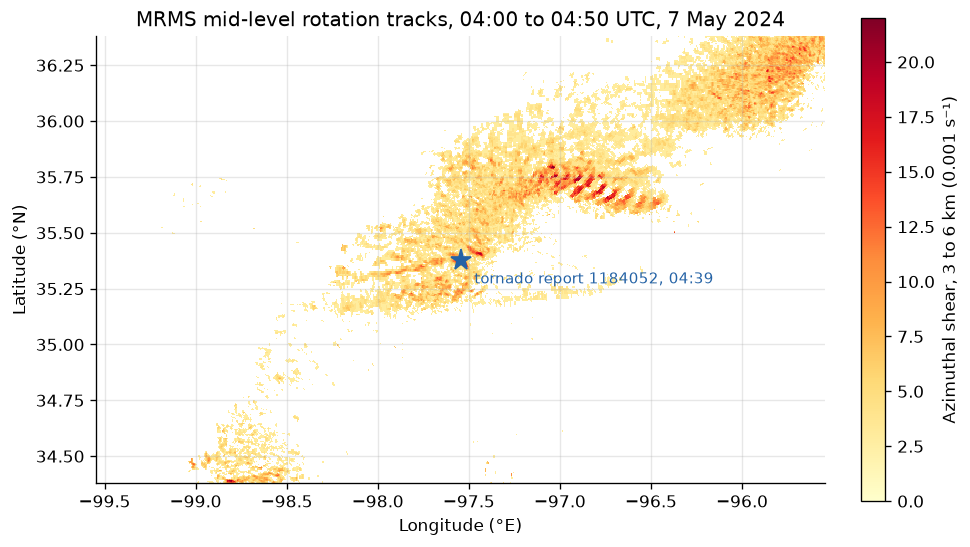

In [6]:
swath = tracks.max("stamp")
fig, ax = plt.subplots(layout="constrained")
mesh = ax.pcolormesh(
    swath.longitude,
    swath.latitude,
    swath.where(swath > 0),
    cmap="YlOrRd",
    vmin=0,
    vmax=22,
    shading="nearest",
    rasterized=True,
)
ax.plot(REPORT_LON, REPORT_LAT, marker="*", markersize=13, color="#2563a6", linestyle="none")
ax.annotate(
    "tornado report 1184052, 04:39",
    (REPORT_LON, REPORT_LAT),
    xytext=(8, -14),
    textcoords="offset points",
    fontsize=9,
    color="#2563a6",
)
ax.set_aspect(1 / np.cos(np.radians(REPORT_LAT)))
ax.set(
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    title="MRMS mid-level rotation tracks, 04:00 to 04:50 UTC, 7 May 2024",
)
fig.colorbar(mesh, ax=ax, label="Azimuthal shear, 3 to 6 km (0.001 s⁻¹)")
plt.show()

Values are whole numbers, so several points often tie at a maximum; each
position below is the mean of the tied points rather than whichever one
`argmax` would pick by array order. The box is 0.25° either side of the
report.

In [7]:
def distance_km(lat, lon):
    """Great-circle distance from the report, on a sphere of radius 6371 km."""
    lat1, lat2 = np.radians(REPORT_LAT), np.radians(lat)
    dlat, dlon = lat2 - lat1, np.radians(lon - REPORT_LON)
    h = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(h))


def peak(box: xr.DataArray) -> dict:
    """The box maximum, how many points tie at it, and their mean position."""
    rows, cols = np.nonzero(box.values >= float(box.max()))
    lat = float(box.latitude.values[rows].mean())
    lon = float(box.longitude.values[cols].mean())
    return {"max": float(box.max()), "tied": len(rows), "km": round(distance_km(lat, lon), 1)}


box = tracks.sel(
    latitude=slice(REPORT_LAT + 0.25, REPORT_LAT - 0.25),
    longitude=slice(REPORT_LON - 0.25, REPORT_LON + 0.25),
)
near = pd.DataFrame(
    [peak(box.isel(stamp=i)) for i in range(box.sizes["stamp"])],
    index=pd.DatetimeIndex(box.stamp.values).strftime("%H:%M").rename("stamp_utc"),
)
strongest = swath.where(swath == swath.max(), drop=True)
print(
    f"Strongest in the crop: {float(swath.max()):.0f} at "
    f"{distance_km(float(strongest.latitude.mean()), float(strongest.longitude.mean())):.0f} km "
    "from the report"
)
near.T

Strongest in the crop: 22 at 65 km from the report


stamp_utc,04:30,04:32,04:34,04:36,04:38,04:40,04:42,04:44,04:46,04:48,04:50
max,13.0,13.0,13.0,13.0,13.0,13.0,18.0,18.0,18.0,18.0,20.0
tied,4.0,4.0,4.0,7.0,7.0,7.0,1.0,1.0,1.0,1.0,1.0
km,19.4,19.4,19.4,16.2,16.2,16.2,0.1,0.1,0.1,0.1,10.1


The report sits at the east end of a swath running in from the west-southwest.
The strongest rotation in the crop lies on a separate swath 65 km to the
northeast, too far away to be the same circulation, and a third runs off the
top right corner. Near the report, the box maximum rises from 13 to 20 across
the window; from 04:42 to 04:48 it sits 0.1 km from the path start, and at
04:50 a stronger value appears 10 km away. Consecutive grids repeat the same value and
position because each holds a thirty-minute maximum: a peak stays put until
it ages out of the window. A rotation track is a shear field, not a tornado
detection, and mid-level values are often high in storms that produce none.

## Pin and cite

`verify` checks every cached file against the lockfile's checksums. Keep the
manifest and lockfile with your analysis; the citation below is what a
methods section needs, and `usdata cite dataset.yaml` prints the same.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:mrms
  NOAA Multi-Radar/Multi-Sensor System (MRMS) was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-mrms-pds
  homepage: https://registry.opendata.aws/noaa-mrms-pds/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 11 checksummed assets (2,028,483 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- Decoding is far larger than downloading. A 180 kB file becomes a 0.39 GB
  array, `--dry-run` reports only the download size, and peak memory over
  eleven sequential opens climbs well past one grid even though each is
  released before the next.
- The [MRMS guide](https://docs.usdata.dev/providers/noaa-mrms/) says to mask
  `-999` and `-99` sentinels. This product has none and no NaN: points without
  shear and points without coverage are both exactly 0.0, and a mask written
  from the guide does nothing.
- The variable is named `RotationTrackML30min`, not the
  `RotationTrackML30min_00.50` the manifest asks for, so the Dataset cannot be
  indexed by the product string; `(name,) = grid.data_vars` finds it.
- The asset's time is one instant, the stamp, although every value is a
  thirty-minute maximum ending there. That changes the reading of every grid
  and appears only in prose.
- Cropping means slicing in the file's frame: latitude north to south and
  longitude 0 to 360. Either mistake returns an empty selection silently and
  fails later at the first reduction.
- Values are quantized to whole units, so up to a dozen points tie at a box
  maximum; `argmax` returns one of them by array order.
- The report's position and time are constants pasted from a separate Storm
  Events fetch, so they are not reproducible from this manifest.

The [tornado classification study](https://usdata.dev/studies/tornado-classification/)
joins these rotation tracks to the report archive itself.